# (1+1)D Viscous Burgers Equation with Physics-Informed Neural Networks

This notebook demonstrates how to solve the **viscous Burgers equation** using Physics-Informed Neural Networks (PINNs). The viscous Burgers equation is:

$$\partial_t u + \partial_x \left( \frac{1}{2} u^2 - \nu \partial_x u \right) = 0, \quad \text{for } (t, x) \in [0, 1] \times [-1, 1]$$

which can be written in convective form as:

$$\partial_t u + u \partial_x u - \nu \partial_{xx} u = 0$$

with initial condition:
$$u(0, x) = \sin(\pi x), \quad \text{for } x \in [-1, 1]$$

and boundary conditions:
$$u(t, -1) = u(t, 1) = 0, \quad \text{for } t \in [0, 1]$$

where:
- $\nu = 0.01/\pi$ is the viscosity coefficient

We will solve this problem using:
1. **Standard PINN**: A single neural network trained on the entire domain
2. **ALPINN (Augmented Lagrangian PINN)**: Enhanced constraint enforcement using Lagrange multipliers

In [1]:
import pinns
pinns.use_backend('jax')  # or 'torch'
# pinns.use_backend('torch')  # or 'torch'
import numpy as np
import matplotlib.pyplot as plt

pinns: Using jax backend


# Define the Problem

In this section, we set up all the components needed to define our PINN problem:
1. Physical parameters (viscosity)
2. The differential equation (residual form)
3. The computational domain
4. Initial and boundary conditions

## Domain of the Problem

We define the (1+1)D space-time domain $\Omega = [0, 1] \times [-1, 1]$ for $(t, x)$.

In [2]:
# Viscosity coefficient
nu = 0.01 / np.pi

domain = pinns.DomainCubic(
    [0, -1],  # t_min, x_min
    [1, 1],   # t_max, x_max
)

## Differential Equation

### The PDE Residual
The `burgers_residual` function computes the residual of the viscous Burgers equation. For PINNs, we train the network to minimize this residual:

$$\mathcal{R} = \partial_t u + u \partial_x u - \nu \partial_{xx} u = 0$$

where $\nu = 0.01/\pi$ is the viscosity coefficient.

In [3]:
# Column convention
# X: (t, x)
# U: u
def burgers_residual(X, U, params, derivative=None):
    # Use passed derivative if available, otherwise use default
    if derivative is None:
        derivative = pinns.derivative
    
    # Get viscosity from params (avoids JAX closure issues)
    nu = params['fixed']['nu']
    
    # Extract coordinates
    t = X[:, 0:1]
    x = X[:, 1:2]
    
    # Extract the output
    u = U[:, 0:1]
    
    # Compute derivatives
    u_t = derivative(u, X, 0, (0,))     # ∂u/∂t
    u_x = derivative(u, X, 0, (1,))     # ∂u/∂x
    u_xx = derivative(u, X, 0, (1, 1))  # ∂²u/∂x²
    
    # Viscous Burgers residual: ∂u/∂t + u·∂u/∂x - ν·∂²u/∂x² = 0
    res = u_t + u * u_x - nu * u_xx

    return res

## Initial and Boundary Conditions

For the viscous Burgers problem, we have:

**Initial condition** at $t = 0$:
$$u(0, x) = -\sin(\pi x), \quad \text{for } x \in [-1, 1]$$

**Boundary conditions** (homogeneous Dirichlet):
$$u(t, -1) = 0 \quad \text{and} \quad u(t, 1) = 0, \quad \text{for } t \in [0, 1]$$

In [4]:
# Initial condition: u(0, x) = sin(πx)
def initial_condition(X):
    x = X[:, 1:2]  # Second column is x
    return -np.sin(np.pi * x)

domain.add_dirichlet(
    boundary=(0, None),  # t = 0 (initial time)
    value=initial_condition,
    component=0,
    name="initial"
)

# Boundary conditions: u(t, -1) = 0 and u(t, 1) = 0
domain.add_dirichlet(
    boundary=(None, 0),  # x = -1 (left boundary)
    value=0.0,
    component=0,
    name="left"
)
domain.add_dirichlet(
    boundary=(None, 1),  # x = 1 (right boundary)
    value=0.0,
    component=0,
    name="right"
)

DomainCubic(xmin=[0.0, -1.0], xmax=[1.0, 1.0], n_conditions=3)

### Reference Solution

The viscous Burgers equation does not have a simple closed-form analytical solution for general initial conditions. We will validate the PINN solution by checking:
- Satisfaction of boundary and initial conditions
- Convergence of the PDE residual

In [5]:
# No analytical solution for viscous Burgers equation
burgers_analytic = None

## Assemble the Problem

The `Problem` class combines all components:
- **domain**: The (1+1)D space-time domain $[0, 1] \times [-1, 1]$
- **model**: The viscous Burgers PDE residual function
- **input_names**: ["t", "x"] - time and spatial coordinates
- **output_names**: ["u"] - the solution field
- **output_range**: Expected range of outputs (based on initial condition range)
- **solution**: None (no analytical solution available)

In [6]:
problem = pinns.Problem(
    domain,
    burgers_residual,
    input_names=["t", "x"],
    output_names=["u"],
    params={'nu': nu},  # Pass nu through params for JAX compatibility
    output_range=[(-1, 1)],
    solution=burgers_analytic
)

# Solve with Standard PINN

## Network Architecture

We use a **Fully Connected Neural Network (FNN)** with:
- **Architecture**: [2, 256, 256, 1] - 2 inputs (t, x), two hidden layers with 256 neurons each, 1 output (u)
- **Activation**: `tanh` - smooth activation suitable for learning smooth physical solutions
- **normalize_input**: `True` - inputs are normalized to improve training
- **unnormalize_output**: `True` - outputs are denormalized using the specified output range

In [7]:
network = pinns.FNN([2, 256, 256, 1], activation="tanh", normalize_input=False, unnormalize_output=False)

## Training Configuration

The trainer is configured with:
- **train_samples**: 5000 PDE points, 100 points for initial condition, 100 points per boundary
- **test_samples**: 5000 PDE points for testing
- **weights**: Equal weighting (1.0) for all loss terms
- **optimizer**: Adam with learning rate $10^{-3}$
- **epochs**: 10,000 training iterations
- **print_each**: Print progress every 1000 epochs

Starting training for 20000 epochs (JIT-compiled)...


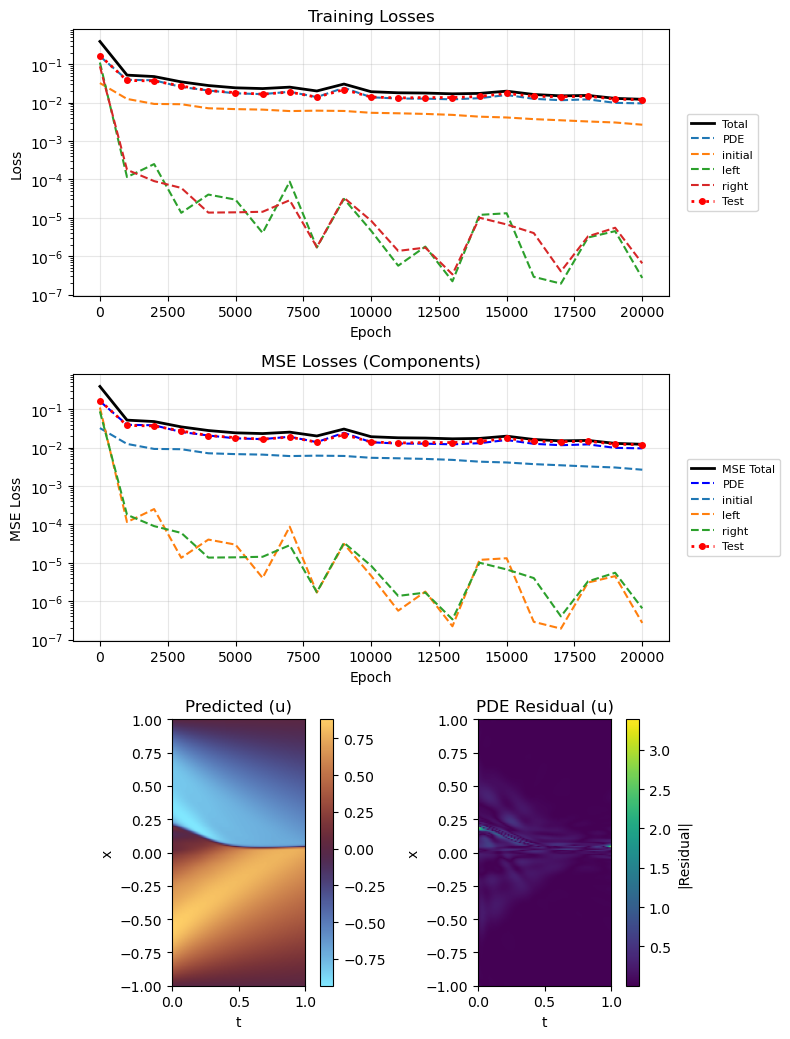

Epoch 0/20000 | Loss: 3.94e-01 | MSE Loss: 3.94e-01 | PDE: 1.62e-01 | BCs: [initial: 3.24e-02, left: 1.11e-01, right: 8.82e-02] | Time: 0.0s | Test Loss: 1.69e-01
Epoch 1000/20000 | Loss: 5.22e-02 | MSE Loss: 5.22e-02 | PDE: 3.94e-02 | BCs: [initial: 1.25e-02, left: 1.15e-04, right: 1.78e-04] | Time: 7.5s | Test Loss: 3.78e-02
Epoch 2000/20000 | Loss: 4.79e-02 | MSE Loss: 4.79e-02 | PDE: 3.83e-02 | BCs: [initial: 9.27e-03, left: 2.51e-04, right: 9.03e-05] | Time: 9.9s | Test Loss: 3.69e-02
Epoch 3000/20000 | Loss: 3.48e-02 | MSE Loss: 3.48e-02 | PDE: 2.56e-02 | BCs: [initial: 9.11e-03, left: 1.35e-05, right: 6.01e-05] | Time: 12.2s | Test Loss: 2.72e-02
Epoch 4000/20000 | Loss: 2.80e-02 | MSE Loss: 2.80e-02 | PDE: 2.08e-02 | BCs: [initial: 7.15e-03, left: 4.03e-05, right: 1.37e-05] | Time: 14.6s | Test Loss: 2.07e-02
Epoch 5000/20000 | Loss: 2.44e-02 | MSE Loss: 2.44e-02 | PDE: 1.75e-02 | BCs: [initial: 6.79e-03, left: 2.98e-05, right: 1.39e-05] | Time: 16.9s | Test Loss: 1.82e-02
Epoc

In [8]:
trainer = pinns.Trainer(
    problem,
    network,
)

trainer.compile(
    train_samples = {
        "pde": 5000,
        "initial": 200,
        "left": 100,
        "right": 100,
    },
    test_samples = {
        "pde": 5000,
        "initial": 0,
        "left": 0,
        "right": 0,
    },
    weights={
        "pde": 1.0,
        "initial": 1.0,
        "left": 1.0,
        "right": 1.0,
    },
    optimizer="adam",
    learning_rate=1e-3,
    epochs=20000,
    print_each=1000,
    show_plots=True,
)

trainer.train()

# Solve with ALPINN (Augmented Lagrangian PINN)

## Network Architecture

For ALPINN, we use the same architecture but with the Augmented Lagrangian training method for improved constraint enforcement.

In [9]:
# No output normalization (paper doesn't use it)
network = pinns.FNN([2, 256, 256, 1], activation="tanh", normalize_input=False, unnormalize_output=False)

## Training Configuration

ALPINN uses the Augmented Lagrangian method to enforce constraints more effectively:
- **weights**: Penalty parameters (β) for each constraint
- **lagrange_constraints**: Which constraints get adaptive Lagrange multipliers
- **lagrange_optimizer**: Optimizer for λ updates (Adam matching AL-PINNs paper)
- **lagrange_lr**: Learning rate for Lagrange multiplier updates

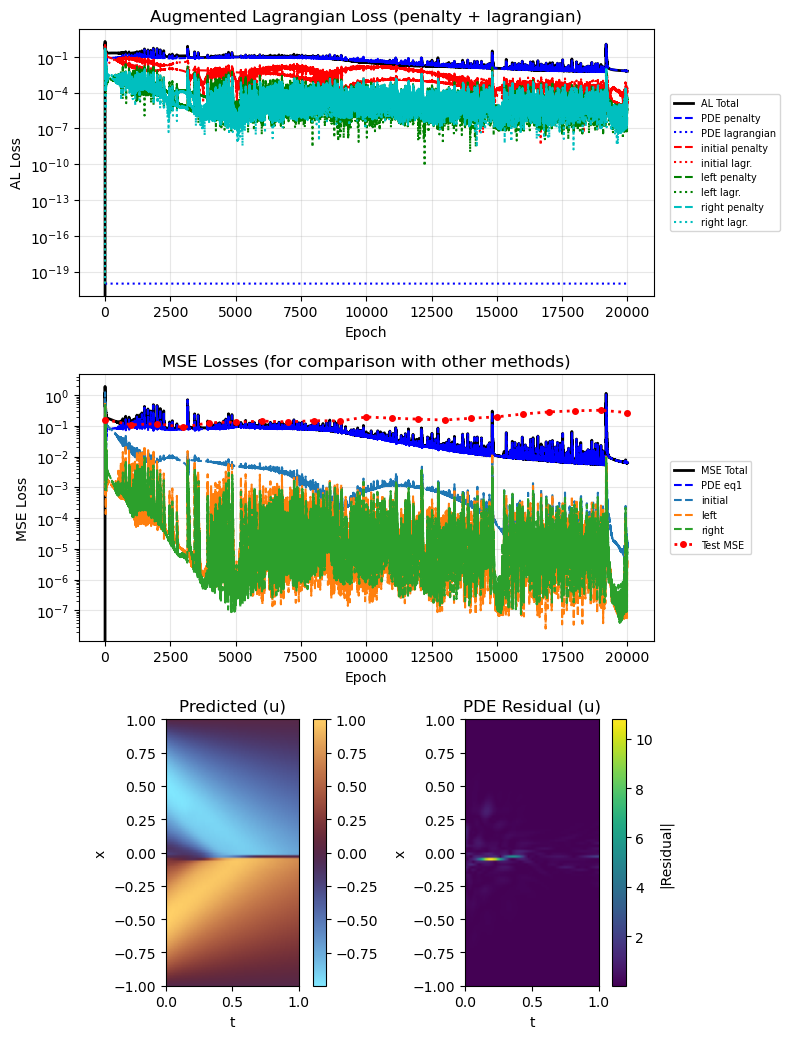

Starting ALTrainer (JAX) for 20000 epochs...
Weights (penalty parameters): {'pde': 1.0, 'initial': 1.0, 'left': 1.0, 'right': 1.0}
λ optimizer: adam, lr: 0.001
Epoch 0/20000 | AL Loss: 0.00e+00 | MSE Loss: 0.00e+00 | PDE: 1.70e-01 | BCs: [initial: 1.61e-01, left: 5.55e-01, right: 4.68e-01] | Time: 0.0s | Test: 1.60e-01
Epoch 1000/20000 | AL Loss: 1.87e-01 | MSE Loss: 1.19e-01 | PDE: 1.02e-01 | BCs: [initial: 1.60e-02, left: 1.58e-04, right: 1.60e-04] | Time: 8.4s | Test: 1.09e-01
Epoch 2000/20000 | AL Loss: 2.15e-01 | MSE Loss: 1.94e-01 | PDE: 1.82e-01 | BCs: [initial: 8.06e-03, left: 3.67e-03, right: 4.48e-04] | Time: 11.6s | Test: 1.18e-01
Epoch 3000/20000 | AL Loss: 1.20e-01 | MSE Loss: 8.37e-02 | PDE: 7.72e-02 | BCs: [initial: 6.45e-03, left: 8.71e-06, right: 6.15e-06] | Time: 14.8s | Test: 9.02e-02
Epoch 4000/20000 | AL Loss: 9.02e-02 | MSE Loss: 8.63e-02 | PDE: 7.95e-02 | BCs: [initial: 6.82e-03, left: 2.43e-06, right: 1.10e-06] | Time: 18.2s | Test: 1.27e-01
Epoch 5000/20000 | A

In [10]:
trainer = pinns.ALTrainer(
    problem,
    network,
)

# ALPINN configuration:
# - Use weights as penalty parameters (β)
# - Lagrange multipliers on initial and boundary conditions
# - Adam optimizer for λ updates (matching AL-PINNs paper)
trainer.compile(
    train_samples = {
        "pde": 2601,  # 51x51 grid
        "initial": 100,
        "left": 50,
        "right": 50,
    },
    test_samples = {
        "pde": 1000,
        "initial": 0,
        "left": 0,
        "right": 0,
    },
    weights={
        "pde": 1.0,
        "initial": 1.0,
        "left": 1.0,
        "right": 1.0,
    },
    optimizer="adam",
    learning_rate=1e-3,
    lagrange_constraints=['initial', 'left', 'right'],  # λ on IC and BCs
    lagrange_optimizer='adam',  # Adam for λ updates (matching paper)
    lagrange_lr=1e-3,
    epochs=20000,
    print_each=1000,
    plot_n_points=100,
    show_plots=True,
)

trainer.train()